In [1]:
import sqlite3
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
sb.set(style = "whitegrid")

In [3]:
conn = sqlite3.connect("Chinook_Sqlite.sqlite")

In [4]:
query_tracks = """
SELECT Track.Name, SUM(InvoiceLine.Quantity) AS Total_Sold, RANK() OVER (ORDER BY SUM(InvoiceLine.Quantity) DESC) AS Sales_Rank
FROM InvoiceLine
JOIN Track ON InvoiceLine.TrackId = Track.TrackId
GROUP BY Track.Name
ORDER BY Sales_Rank
LIMIT 10;
"""
df_tracks = pd.read_sql_query(query_tracks, conn)
df_tracks

,Name,Total_Sold,Sales_Rank
0,The Trooper,5,1
1,Untitled,4,2
2,The Number Of The Beast,4,2
3,Sure Know Something,4,2
4,Hallowed Be Thy Name,4,2
5,Eruption,4,2
6,Where Eagles Dare,3,7
7,Welcome Home (Sanitarium),3,7
8,Sweetest Thing,3,7
9,Surrender,3,7


In [5]:
query_region = """
SELECT Customer.Country, SUM(InvoiceLine.Quantity * InvoiceLine.UnitPrice) AS Total_Revenue
FROM Invoice
JOIN Customer ON Invoice.CustomerId = Customer.CustomerId
JOIN InvoiceLine ON Invoice.InvoiceId = InvoiceLine.InvoiceId
GROUP BY Customer.Country
ORDER BY Total_Revenue DESC;
"""
df_region = pd.read_sql_query(query_region, conn)
df_region

,Country,Total_Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


In [6]:
query_month = """
SELECT strftime('%Y-%m', Invoice.InvoiceDate) AS Month, SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity) AS Total_Revenue,RANK() OVER (ORDER BY SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity) DESC) AS Month_Rank
FROM Invoice
JOIN InvoiceLine ON Invoice.InvoiceId = InvoiceLine.InvoiceId
GROUP BY Month
ORDER BY Month;
"""
df_month = pd.read_sql_query(query_month, conn)
df_month

,Month,Total_Revenue,Month_Rank
0,2009-01,35.64,57
1,2009-02,37.62,13
2,2009-03,37.62,13
3,2009-04,37.62,13
4,2009-05,37.62,13
5,2009-06,37.62,13
6,2009-07,37.62,13
7,2009-08,37.62,13
8,2009-09,37.62,13
9,2009-10,37.62,13


In [7]:
query_genre = """
SELECT Genre.Name AS Genre, SUM(InvoiceLine.Quantity) AS Total_Sold
FROM InvoiceLine
JOIN Track ON InvoiceLine.TrackId = Track.TrackId
JOIN Genre ON Track.GenreId = Genre.GenreId
GROUP BY Genre.Name
ORDER BY Total_Sold DESC;
"""
df_genre = pd.read_sql_query(query_genre, conn)
df_genre

,Genre,Total_Sold
0,Rock,835
1,Latin,386
2,Metal,264
3,Alternative & Punk,244
4,Jazz,80
5,Blues,61
6,TV Shows,47
7,R&B/Soul,41
8,Classical,41
9,Reggae,30


C:\Users\Jinzo\AppData\Local\Temp\ipykernel_15680\5933376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x="Total_Sold", y="Name", data=df_tracks, palette="viridis")


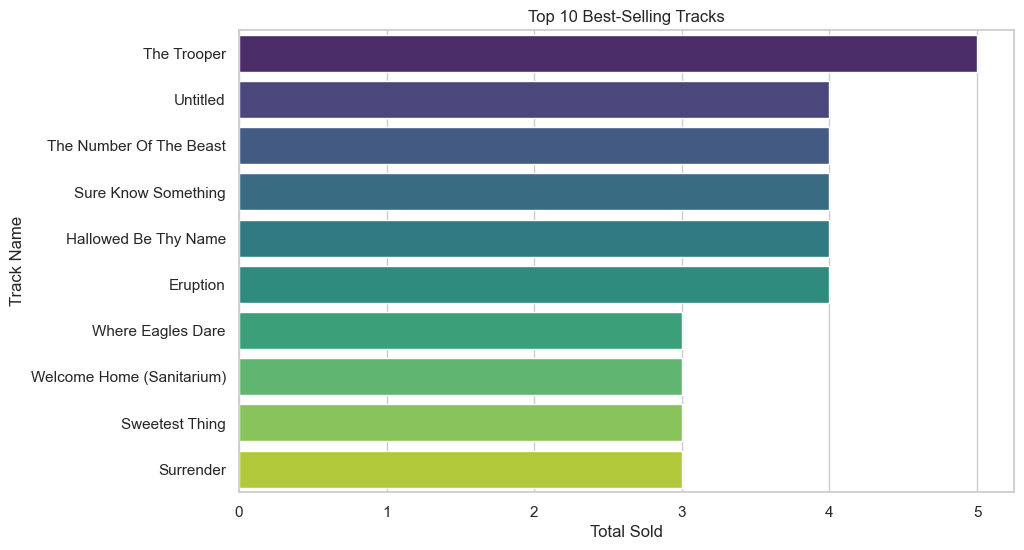

In [9]:
plt.figure(figsize=(10,6))
sb.barplot(x="Total_Sold", y="Name", data=df_tracks, palette="viridis")
plt.title("Top 10 Best-Selling Tracks")
plt.xlabel("Total Sold")
plt.ylabel("Track Name")
plt.show()

C:\Users\Jinzo\AppData\Local\Temp\ipykernel_15680\2437187315.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x="Total_Revenue", y="Country", data=df_region, palette="magma")


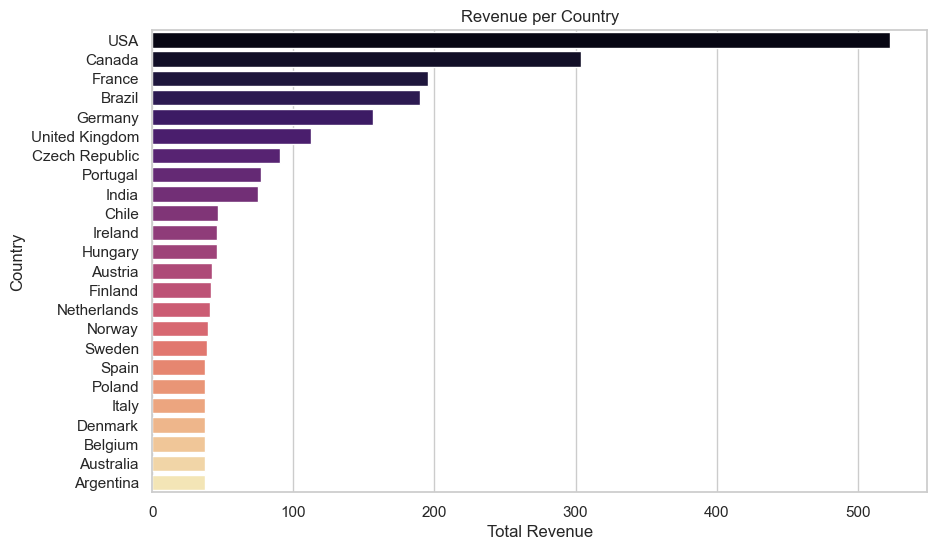

In [11]:
plt.figure(figsize=(10,6))
sb.barplot(x="Total_Revenue", y="Country", data=df_region, palette="magma")
plt.title("Revenue per Country")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.show()

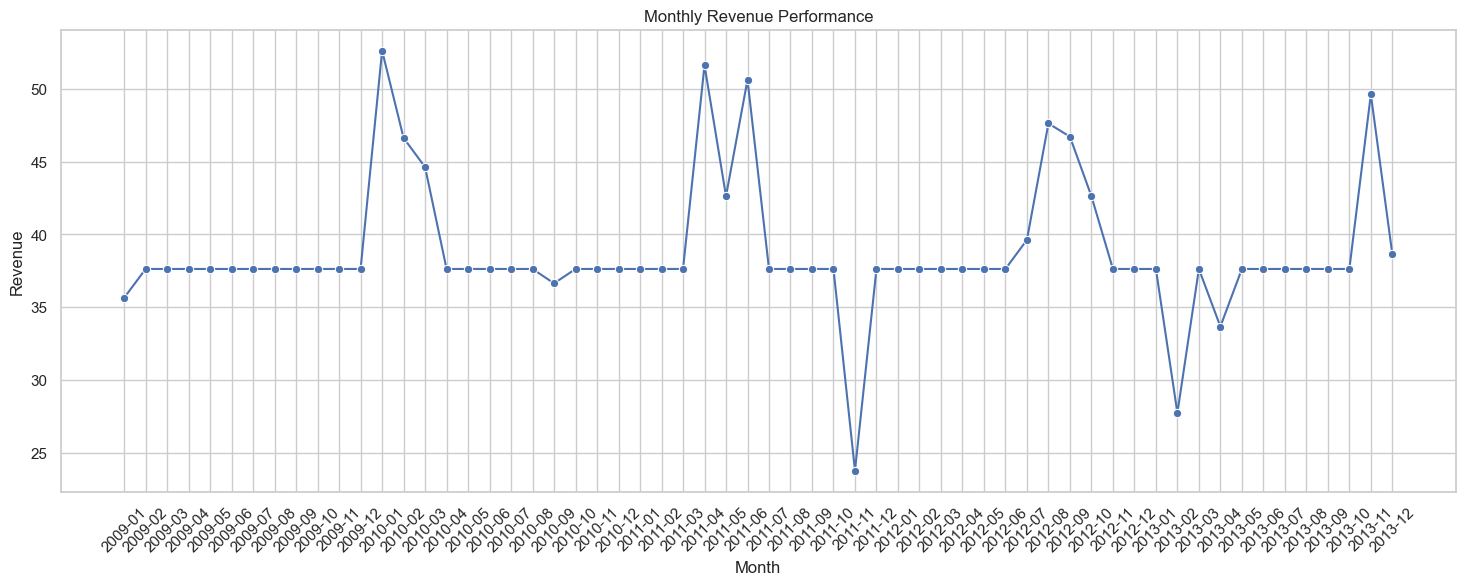

In [23]:
plt.figure(figsize=(18,6))
sb.lineplot(x="Month", y="Total_Revenue", data=df_month, marker="o")
plt.title("Monthly Revenue Performance")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

C:\Users\Jinzo\AppData\Local\Temp\ipykernel_15680\2502212137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x="Total_Sold", y="Genre", data=df_genre, palette="viridis")


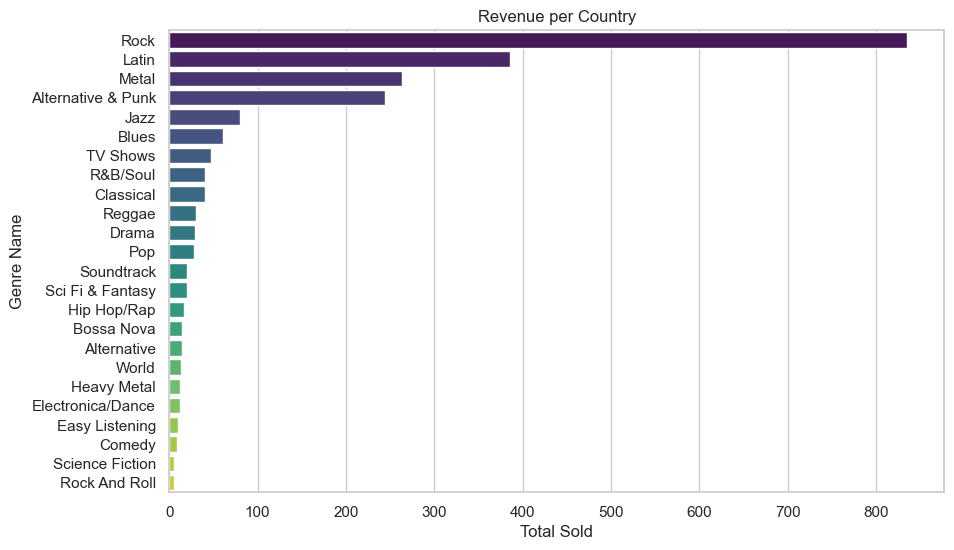

In [18]:
plt.figure(figsize=(10,6))
sb.barplot(x="Total_Sold", y="Genre", data=df_genre, palette="viridis")
plt.title("Revenue per Country")
plt.xlabel("Total Sold")
plt.ylabel("Genre Name")
plt.show()